In [ ]:
import torch.nn as nn
import torch
import matplotlib.pyplot as plt

### Defining the Model

For this section, we are defining the model being used which is a simple one layer transformer model. The main thing that differentiates this from other transformers is in the self attention mechanism where I did not use masking to ensure causal attention which may be more useful in data that comprises of long sequences of words. I was curious to see if this would help this model learn more efficiently here. However, I did use masking to prevent token embeddings from attending to padding emeddeings which I added to ensure that all words were the same length.

In [3]:
class POS_Transformer (nn.Module):
    def __init__ (self, embed_dim, num_heads, hidden_dim, num_pos_tags):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.num_pos_tags = num_pos_tags

        self.MHA = nn.MultiheadAttention(self.embed_dim, self.num_heads, batch_first=True)
        self.MLP = nn.Sequential(
            nn.Linear(self.embed_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.embed_dim)
        )
        self.layernorm1 = nn.LayerNorm(self.embed_dim)
        self.layernorm2 = nn.LayerNorm(self.embed_dim)
        self.unembed = nn.Linear(self.embed_dim, self.num_pos_tags)

    def forward(self, x, attention_mask):
        attention_out = self.MHA(x, x, x, key_padding_mask=attention_mask)[0]
        x = self.layernorm1(attention_out + x)
        mlp_out = self.MLP(x)
        x = self.layernorm2(mlp_out + x)
        cls_output = x[:, 0, :]  # take CLS token
        return self.unembed(cls_output)


### Creating DataLoader

In [4]:
from torch.utils.data import Dataset, DataLoader, random_split

pos_to_idx = {'nouns': 0, 'adjectives': 1, 'adverbs': 2, 'verbs': 3}

class POSDataset(Dataset):
    def __init__(self, data, pos_to_idx):
        self.data = data
        self.pos_to_idx = pos_to_idx
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            'embeddings': item['embedding'],
            'attention_mask': item['padding_mask'],
            'labels': torch.tensor(self.pos_to_idx[item['pos']], dtype=torch.long)
        }

data = torch.load('Data/word_embeddings.pt')

dataset = POSDataset(data, pos_to_idx)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Improving the Model

Here I am running a grid search to find the best number of heads and hidden dimensions for to get the lowest validation loss under 3 epochs. I reduced the number of epochs because this seems to be where trainging peaked on the baseline run.

In [17]:
num_heads = [3, 4, 6, 8]
hidden_dim = [175, 192, 200, 212, 225]

val_loss = []

for heads in num_heads:
    head_list = []
    print(f"Training with {heads} heads...")
    for hidden in hidden_dim:
        print(f"  Hidden dimension: {hidden}")
        model = POS_Transformer(embed_dim=768, num_heads=heads, hidden_dim=hidden, num_pos_tags=4)
        criterion = nn.CrossEntropyLoss()  
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        device = torch.device('mps' if torch.mps.is_available() else 'cpu')
        model.to(device)

        def train_epoch(model, dataloader, optimizer, criterion, device):
            model.train()
            total_loss = 0
            correct = 0
            total = 0

            for batch in dataloader:
                embeddings = batch['embeddings'].to(device)    
                labels = batch['labels'].to(device)            
                attention_mask = batch['attention_mask'].to(device) 

                optimizer.zero_grad()

                logits = model(embeddings, attention_mask)     

                loss = criterion(logits, labels)

                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

            return total_loss / len(dataloader), correct / total


        def evaluate(model, dataloader, criterion, device):
            model.eval()
            total_loss = 0
            correct = 0
            total = 0

            with torch.no_grad():
                for batch in dataloader:
                    embeddings = batch['embeddings'].to(device)
                    labels = batch['labels'].to(device)
                    attention_mask = batch['attention_mask'].to(device)

                    logits = model(embeddings, attention_mask)
                    loss = criterion(logits, labels)

                    total_loss += loss.item()
                    preds = logits.argmax(dim=1)
                    correct += (preds == labels).sum().item()
                    total += labels.size(0)

            return total_loss / len(dataloader), correct / total


        num_epochs = 3
        final_val_loss = 0

        for epoch in range(num_epochs):
            train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss_epoch, val_acc = evaluate(model, val_loader, criterion, device)

            if epoch == num_epochs - 1:
                final_val_loss = val_loss_epoch
            
        head_list.append(final_val_loss)
        print(f"    Final Validation Loss: {final_val_loss:.4f}")

    val_loss.append(head_list)



Training with 3 heads...
  Hidden dimension: 175
    Final Validation Loss: 0.5486
  Hidden dimension: 192
    Final Validation Loss: 0.5535
  Hidden dimension: 200
    Final Validation Loss: 0.5365
  Hidden dimension: 212
    Final Validation Loss: 0.5378
  Hidden dimension: 225
    Final Validation Loss: 0.5338
Training with 4 heads...
  Hidden dimension: 175
    Final Validation Loss: 0.5493
  Hidden dimension: 192
    Final Validation Loss: 0.5469
  Hidden dimension: 200
    Final Validation Loss: 0.5573
  Hidden dimension: 212
    Final Validation Loss: 0.5515
  Hidden dimension: 225
    Final Validation Loss: 0.5509
Training with 6 heads...
  Hidden dimension: 175
    Final Validation Loss: 0.5351
  Hidden dimension: 192
    Final Validation Loss: 0.5274
  Hidden dimension: 200
    Final Validation Loss: 0.5395
  Hidden dimension: 212
    Final Validation Loss: 0.5596
  Hidden dimension: 225
    Final Validation Loss: 0.5360
Training with 8 heads...
  Hidden dimension: 175
    Fi

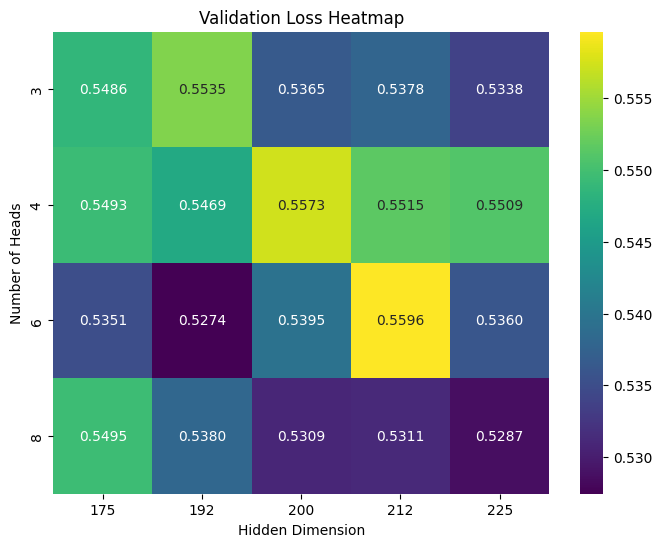

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to numpy array
val_loss_array = np.array(val_loss)

plt.figure(figsize=(8, 6))

sns.heatmap(
    val_loss_array,
    annot=True,
    fmt=".4f",
    xticklabels=hidden_dim,
    yticklabels=num_heads,
    cmap="viridis"
)

plt.xlabel("Hidden Dimension")
plt.ylabel("Number of Heads")
plt.title("Validation Loss Heatmap")

plt.show()

### Evaluating the Model

This is what I will be using to evalue the model on its optimal settings

In [25]:
model = POS_Transformer(embed_dim=768, num_heads=6, hidden_dim=192, num_pos_tags=4)
criterion = nn.CrossEntropyLoss()  
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-1)

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model.to(device)

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in dataloader:
        embeddings = batch['embeddings'].to(device)    
        labels = batch['labels'].to(device)            
        attention_mask = batch['attention_mask'].to(device) 

        optimizer.zero_grad()

        logits = model(embeddings, attention_mask)     

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch['embeddings'].to(device)
            labels = batch['labels'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            logits = model(embeddings, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(dataloader), correct / total


num_epochs = 10

val_losses_history = []
train_losses_history = []
val_acc_history = []
train_acc_history = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    val_losses_history.append(val_loss)
    train_losses_history.append(train_loss)
    val_acc_history.append(val_acc)
    train_acc_history.append(train_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.8466 Acc: 0.6978 | Val Loss: 0.6996 Acc: 0.7352
Epoch 2/10 | Train Loss: 0.6472 Acc: 0.7811 | Val Loss: 0.6373 Acc: 0.7618
Epoch 3/10 | Train Loss: 0.6076 Acc: 0.7901 | Val Loss: 0.6113 Acc: 0.7825
Epoch 4/10 | Train Loss: 0.5888 Acc: 0.7867 | Val Loss: 0.5964 Acc: 0.7781
Epoch 5/10 | Train Loss: 0.5655 Acc: 0.7939 | Val Loss: 0.5744 Acc: 0.7879
Epoch 6/10 | Train Loss: 0.5514 Acc: 0.7969 | Val Loss: 0.5771 Acc: 0.7879
Epoch 7/10 | Train Loss: 0.5437 Acc: 0.8009 | Val Loss: 0.5823 Acc: 0.7836
Epoch 8/10 | Train Loss: 0.5388 Acc: 0.8032 | Val Loss: 0.6052 Acc: 0.7613
Epoch 9/10 | Train Loss: 0.5319 Acc: 0.8059 | Val Loss: 0.5583 Acc: 0.7966
Epoch 10/10 | Train Loss: 0.5250 Acc: 0.8068 | Val Loss: 0.6116 Acc: 0.7651


### Plotting and Analysis

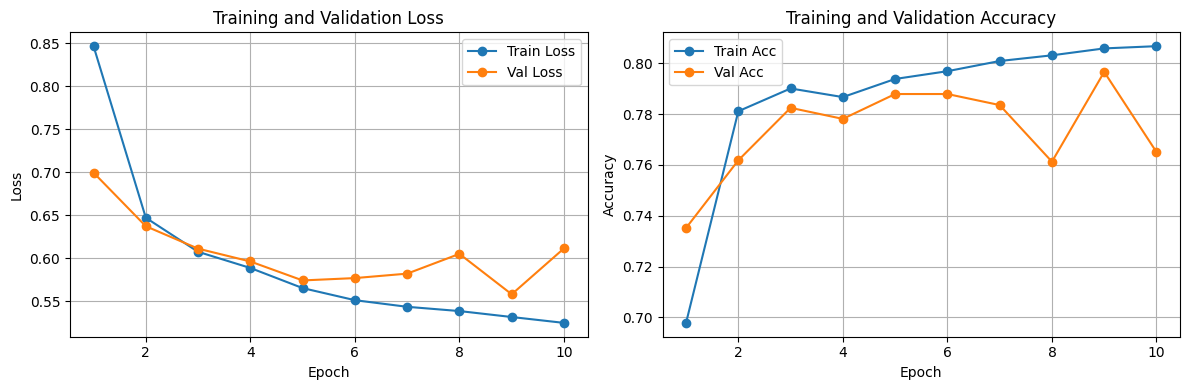

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, num_epochs + 1)

axes[0].plot(epochs, train_losses_history, label='Train Loss', marker='o')
axes[0].plot(epochs, val_losses_history, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_acc_history, label='Train Acc', marker='o')
axes[1].plot(epochs, val_acc_history, label='Val Acc', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()